# Conditional GAN (cGAN)

## Motivation

A standard GAN generates images from random noise but does not allow control over the output class.

A Conditional GAN adds a condition (y), such as a class label, to both the Generator and Discriminator:

$
G(z, y) \rightarrow x
$


## Paper

**Conditional Generative Adversarial Nets**
Mirza and Osindero, 2014

https://arxiv.org/abs/1411.1784



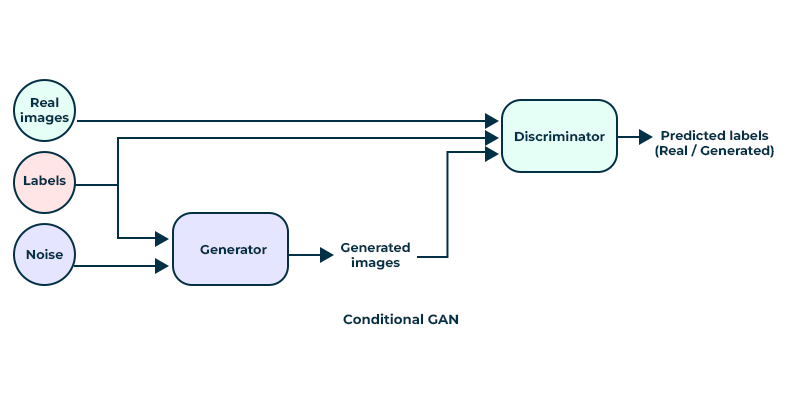

In [2]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import kagglehub

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

In [3]:
epochs = 100
learning_rate = 2e-4
batch_size = 64
z = 100
embedding_dim = 50
image_size = 64
num_classes = 2

## 1- Downloading and Preparing the Dataset

The dataset is restricted to the **cat** and **dog** classes.

In [5]:
download_path = kagglehub.dataset_download("andrewmvd/animal-faces")

data_dir = os.path.join(download_path, "afhq", "train")

transform = transforms.Compose([
    transforms.Resize(
        (image_size, image_size),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

Using Colab cache for faster access to the 'animal-faces' dataset.


In [6]:
class_names = ["cat", "dog"]
selected_labels = [full_dataset.class_to_idx[name] for name in class_names]

animal_dataset = torch.utils.data.Subset(
    full_dataset,
    [
        i for i, label in enumerate(full_dataset.targets)
        if label in selected_labels
    ]
)

train_dataloader = DataLoader(
    animal_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

print("Classes:", class_names)
print("Number of images:", len(animal_dataset))

Classes: ['cat', 'dog']
Number of images: 9892


## 2- Visualizing the Dataset

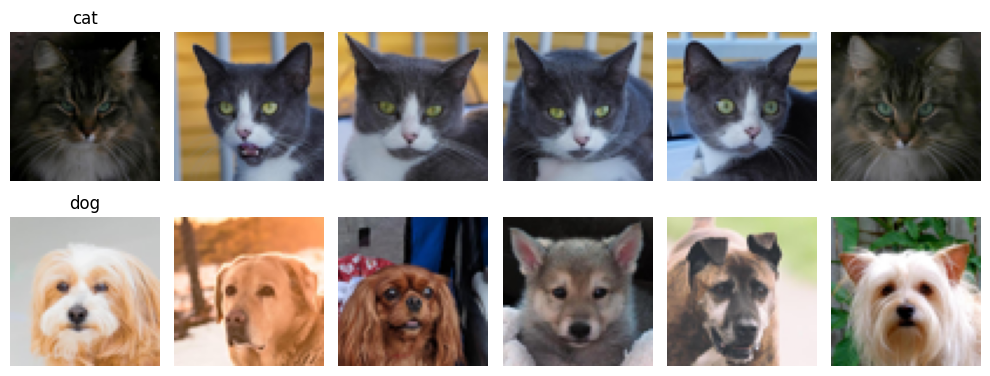

In [7]:
fig, axes = plt.subplots(num_classes, 6, figsize=(10, 4))

for class_id in range(num_classes):
    class_images = [
        image for image, label in animal_dataset
        if label == class_id
    ][:6]

    for column, image in enumerate(class_images):
        image = (image + 1) / 2
        image = image.permute(1, 2, 0)

        axes[class_id, column].imshow(image)
        axes[class_id, column].axis("off")

    axes[class_id, 0].set_title(class_names[class_id])

plt.tight_layout()
plt.show()

## 3- Conditional Generator

The class label is converted into a learned embedding and combined with the noise vector.

In [10]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

 #[ 0.20, -0.70,  1.10,  0.40],  # label 0 → Cat
 #[-0.50,  0.80,  0.30, -1.20],  # label 1 → Dog

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.model = nn.Sequential(
            nn.ConvTranspose2d(
                z + embedding_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_features = self.label_embedding(labels)
        x = torch.cat((noise, label_features), dim=1)
        x = x.view(x.size(0), z + embedding_dim, 1, 1)
        return self.model(x)

## 4- Conditional Discriminator

The class embedding is reshaped into an image-sized condition map and combined with the input image.

In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
#Class 0, Cat:
#[0.2, 0.1, -0.4, 0.8,
 #0.7, 0.3,  0.2, 0.5,
 #0.1, 0.9, -0.2, 0.4,
 #0.6, 0.2,  0.3, 0.7]

#Class 1, Dog:
#[-0.5, 0.8, 0.1, -0.3,
 # 0.6, 0.2, 0.9,  0.4,
 #-0.1, 0.7, 0.5,  0.2,
 # 0.3, 0.6, 0.1, -0.4]
        self.label_embedding = nn.Embedding(
            num_classes,
            image_size * image_size
        )

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        )

    def forward(self, images, labels):
        label_map = self.label_embedding(labels)
        label_map = label_map.view(
            labels.size(0),1,image_size,image_size
        )

        x = torch.cat((images, label_map), dim=1)
        return self.model(x).view(-1)

## 5- Initialize the Models

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def weights_init(layer):
    if isinstance(layer,(nn.Conv2d, nn.ConvTranspose2d, nn.Embedding)):
        nn.init.normal_(layer.weight, 0.0, 0.02)

    elif isinstance(layer, nn.BatchNorm2d):
        nn.init.normal_(layer.weight, 1.0, 0.02)
        nn.init.constant_(layer.bias, 0)


generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

print("Device:", device)

Device: cpu


## 6- Loss Function and Optimizers

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer_g = torch.optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_d = torch.optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

## 7- Training

Real images with incorrect labels are also shown to the Discriminator as fake examples.

In [ ]:
generator_losses = []
discriminator_losses = []

for epoch in range(epochs):
    generator_loss_total = 0
    discriminator_loss_total = 0

    progress = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{epochs}",
        leave=False
    )

    for real_images, real_labels in progress:
        real_images = real_images.to(device, non_blocking=True)
        real_labels = real_labels.to(device, non_blocking=True)

        current_batch_size = real_images.size(0)


        real_targets = torch.full((current_batch_size,),0.9, device=device)
#Real images → [0.9, 0.9, 0.9, 0.9]
        fake_targets = torch.zeros(current_batch_size,device=device)
#Fake images → [0.0, 0.0, 0.0, 0.0]
        wrong_labels = 1 - real_labels
#cat = 0 → wrong label = 1
#dog = 1 → wrong label = 0
        optimizer_d.zero_grad(set_to_none=True)
#Prediction: [0.8, 0.7, 0.6, 0.9]
#Target:     [0.9, 0.9, 0.9, 0.9]
        real_loss = loss_fn(
            discriminator(real_images, real_labels),
            real_targets
        )

#Real cat image + dog label → target = 0
#Real dog image + cat label → target = 0
        wrong_label_loss = loss_fn(
            discriminator(real_images, wrong_labels),
            fake_targets
        )

#Fake image 1 → generate cat
#Fake image 2 → generate dog
#Fake image 3 → generate dog
#Fake image 4 → generate cat
#Fake image 5 → generate dog
        fake_labels = torch.randint(0,
            num_classes,
            (current_batch_size,),
            device=device
        )
#Image 1 → 100 random values
#Image 2 → 100 random values
#Image 3 → 100 random values
#Image 4 → 100 random values
        noise = torch.randn(
            current_batch_size,
            z,
            device=device
        )

        fake_images = generator(noise, fake_labels)
#Generated cat prediction = 0.7, target = 0
#Generated dog prediction = 0.2, target = 0
        fake_loss = loss_fn(
            discriminator(fake_images.detach(), fake_labels),
            fake_targets
        )
# 1. Real image + correct label
# 2. Real image + wrong label
# 3. Fake image + generated label
        discriminator_loss = (
            real_loss + wrong_label_loss + fake_loss
        ) / 3

        discriminator_loss.backward()
        optimizer_d.step()

        for parameter in discriminator.parameters():
            parameter.requires_grad_(False)

        optimizer_g.zero_grad(set_to_none=True)
#Generated image 1 → dog
#Generated image 2 → cat
#Generated image 3 → dog
#Generated image 4 → dog
        generator_labels = torch.randint(
            0,
            num_classes,
            (current_batch_size,),
            device=device
        )

        noise = torch.randn(
            current_batch_size,
            z,
            device=device
        )

        generated_images = generator(
            noise,
            generator_labels
        )
#0 → generate cat
#1 → generate dog
#1 → generate dog
#0 → generate cat
        generator_loss = loss_fn(
            discriminator(
                ,m....,
                generator_labels
            ),
            torch.ones(current_batch_size, device=device)
        )

        generator_loss.backward()
        optimizer_g.step()

        for parameter in discriminator.parameters():
            parameter.requires_grad_(True)

        generator_loss_total += generator_loss.item()
        discriminator_loss_total += discriminator_loss.item()

    generator_epoch_loss = (
        generator_loss_total / len(train_dataloader)
    )

    discriminator_epoch_loss = (
        discriminator_loss_total / len(train_dataloader)
    )

    generator_losses.append(generator_epoch_loss)
    discriminator_losses.append(discriminator_epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Generator: {generator_epoch_loss:.4f} | "
        f"Discriminator: {discriminator_epoch_loss:.4f}"
    )

Epoch [1/100] Generator: 7.3539 | Discriminator: 0.5662


Epoch [2/100] Generator: 3.3923 | Discriminator: 0.5325


Epoch [3/100] Generator: 4.5869 | Discriminator: 0.4498


Epoch [4/100] Generator: 4.4135 | Discriminator: 0.3826


Epoch [5/100] Generator: 4.5778 | Discriminator: 0.3510


...

Epoch [96/100] Generator: 3.4218 | Discriminator: 0.1826


Epoch [97/100] Generator: 3.4499 | Discriminator: 0.2964


Epoch [98/100] Generator: 3.0984 | Discriminator: 0.1939


Epoch [99/100] Generator: 3.2932 | Discriminator: 0.1747


Epoch [100/100] Generator: 3.3334 | Discriminator: 0.1698


## 8- Training Loss

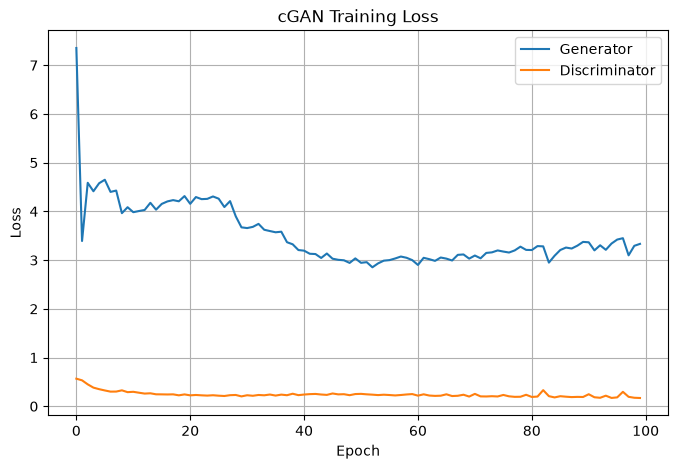

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(generator_losses, label="Generator")
plt.plot(discriminator_losses, label="Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## 9- Generate Animals by Class

The same noise vectors are used for both classes.

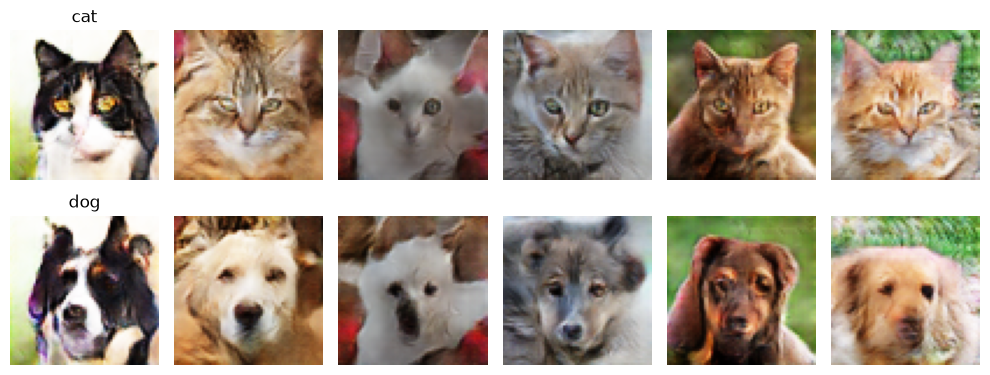

Generator(
  (label_embedding): Embedding(2, 50)
  (model): Sequential(
    (0): ConvTranspose2d(150, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 

In [ ]:
samples_per_class = 6
fixed_noise = torch.randn(
    samples_per_class,
    z,
    device=device
)

fig, axes = plt.subplots(
    num_classes,
    samples_per_class,
    figsize=(10, 4)
)

generator.eval()

with torch.no_grad():
    for class_id in range(num_classes):
        labels = torch.full(
            (samples_per_class,),
            class_id,
            device=device,
            dtype=torch.long
        )

        generated_images = generator(
            fixed_noise,
            labels
        )

        generated_images = (
            generated_images.clamp(-1, 1) + 1
        ) / 2

        for column in range(samples_per_class):
            image = generated_images[column]
            image = image.permute(1, 2, 0).cpu()

            axes[class_id, column].imshow(image)
            axes[class_id, column].axis("off")

            if column == 0:
                axes[class_id, column].set_title(
                    class_names[class_id]
                )

plt.tight_layout()
plt.show()


Contributed by :Lama